# Support Vector Machines — Functional and Geometric Margins

## Learning Objectives
- Define the **functional margin** and explain what it measures about classifier confidence
- Explain why the functional margin is **scale-sensitive** and therefore unreliable on its own
- Define the **geometric margin** as the scale-invariant perpendicular distance to the hyperplane
- Prove that rescaling $(w, b) \to (cw, cb)$ leaves the geometric margin unchanged
- Define the **margin of a training set** as the minimum per-example geometric margin
- Apply the **canonical normalisation** (functional margin = 1) to fix scale freedom
- Derive the **margin width formula** $\tfrac{2}{\|w\|}$ under the canonical form

## Problem Setup

We work with a binary classification problem. Given a training set

$$\mathcal{D} = \{(x^{(i)}, y^{(i)})\}_{i=1}^{n}, \quad x^{(i)} \in \mathbb{R}^d, \quad y^{(i)} \in \{-1, +1\}$$

a **linear classifier** separates the two classes with a hyperplane

$$\mathcal{H} = \{x \in \mathbb{R}^d : w^T x + b = 0\}, \quad w \in \mathbb{R}^d,\; b \in \mathbb{R}$$

and predicts labels via

$$\hat{y} = \operatorname{sign}(w^T x + b)$$

Many such hyperplanes can correctly separate the data. The SVM criterion for choosing *which one* requires formalising the notion of **margin** — a measure of how far the closest training points are from the decision boundary.

| Symbol | Meaning |
|---|---|
| $w \in \mathbb{R}^d$ | Normal vector to the decision hyperplane |
| $b \in \mathbb{R}$ | Bias (offset of hyperplane from origin) |
| $\hat{\gamma}^{(i)}$ | Functional margin of the $i$-th example |
| $\gamma^{(i)}$ | Geometric margin of the $i$-th example |
| $\hat{\gamma}$ | Functional margin of the training set |
| $\gamma$ | Geometric margin of the training set |

## 1. Functional Margin

### Definition

The **functional margin** of the $i$-th training example with respect to parameters $(w, b)$ is:

$$\boxed{\hat{\gamma}^{(i)} = y^{(i)}\bigl(w^T x^{(i)} + b\bigr)}$$

### What it measures

The raw score $w^T x^{(i)} + b$ is a signed distance-like quantity:
- **Positive** when $x^{(i)}$ is on the positive side of $\mathcal{H}$
- **Negative** when $x^{(i)}$ is on the negative side
- **Zero** when $x^{(i)}$ lies exactly on $\mathcal{H}$

Multiplying by $y^{(i)}$ flips the sign so that:

| Condition | Meaning |
|---|---|
| $\hat{\gamma}^{(i)} > 0$ | $x^{(i)}$ is **correctly classified**; larger value = higher confidence |
| $\hat{\gamma}^{(i)} = 0$ | $x^{(i)}$ lies on the decision boundary |
| $\hat{\gamma}^{(i)} < 0$ | $x^{(i)}$ is **misclassified** |

### Functional margin of the training set

The margin of the entire dataset is the **minimum** per-example margin — the confidence on the hardest training point:

$$\hat{\gamma} = \min_{i = 1,\ldots,n} \hat{\gamma}^{(i)}$$

A good classifier should maximise $\hat{\gamma}$.

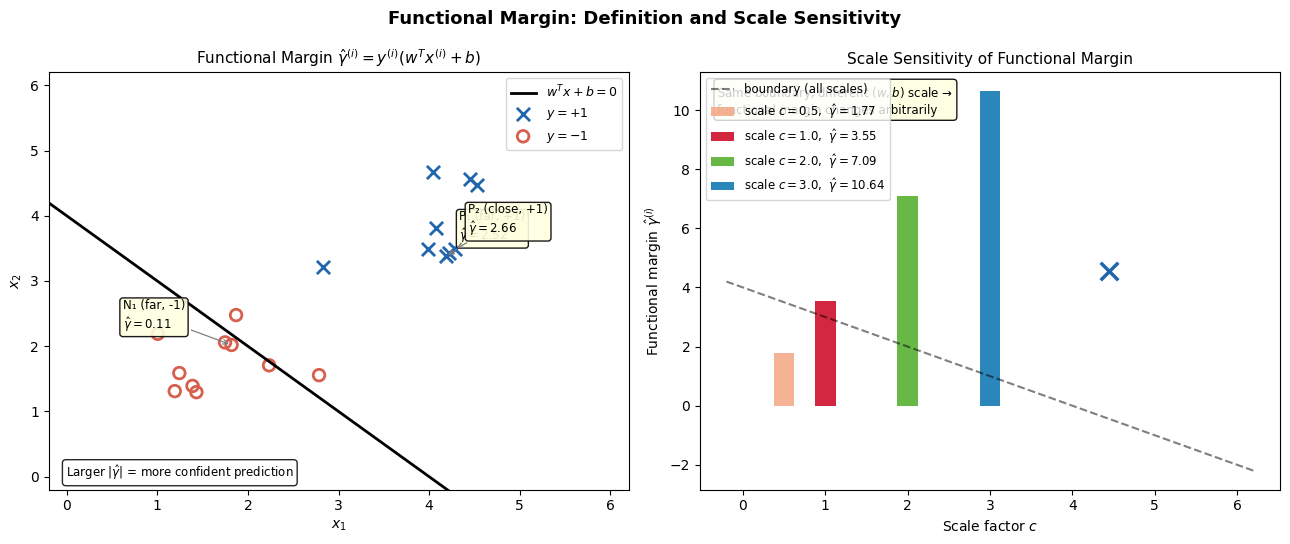

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

rng = np.random.default_rng(42)
pos = rng.normal(loc=[4.0, 4.0], scale=0.6, size=(10, 2))
neg = rng.normal(loc=[1.5, 1.8], scale=0.6, size=(10, 2))

# boundary: w=[1,1]/√2, b=-4/√2  → x2 = 4 - x1
w = np.array([1., 1.]) / np.sqrt(2)
b = -4. / np.sqrt(2)

xr = np.linspace(-0.2, 6.2, 200)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ─── Left: annotated functional margins ──────────────────────────────────
ax = axes[0]
ax.plot(xr, 4 - xr, 'k-', lw=2, label='$w^Tx + b = 0$')
ax.scatter(pos[:, 0], pos[:, 1], marker='x', s=90, c='#2166ac', linewidths=2, label='$y=+1$')
ax.scatter(neg[:, 0], neg[:, 1], marker='o', s=70, facecolors='none',
           edgecolors='#d6604d', linewidths=2, label='$y=-1$')

# annotate three selected points
selected = [
    (pos[0], +1, 'P₁ (far, +1)'),
    (pos[7], +1, 'P₂ (close, +1)'),
    (neg[3], -1, 'N₁ (far, -1)'),
]
for pt, yi, name in selected:
    fm = yi * (w @ pt + b)
    # offset text so annotations don't overlap
    dx, dy = (0.15, 0.25) if yi == 1 else (-1.2, 0.25)
    ax.annotate(
        f'{name}\n$\\hat{{\\gamma}}={fm:.2f}$',
        pt, xytext=(pt[0] + dx, pt[1] + dy), fontsize=8.5,
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.9),
        bbox=dict(boxstyle='round,pad=0.25', fc='lightyellow', alpha=0.9)
    )

ax.set_xlim(-0.2, 6.2); ax.set_ylim(-0.2, 6.2)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Functional Margin $\\hat{\\gamma}^{(i)} = y^{(i)}(w^Tx^{(i)}+b)$', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.text(0.03, 0.03,
        'Larger $|\\hat{\\gamma}|$ = more confident prediction',
        transform=ax.transAxes, fontsize=8.5,
        bbox=dict(boxstyle='round', fc='white', alpha=0.85))

# ─── Right: scale sensitivity — doubling (w,b) doubles functional margin ─
ax = axes[1]
scales = [0.5, 1.0, 2.0, 3.0]
colors = ['#f4a582', '#ca0020', '#4dac26', '#0571b0']
# pick one representative positive point
pt = pos[1]
yi = +1.0

ax.scatter([pt[0]], [pt[1]], marker='x', s=160, c='#2166ac', linewidths=2.5, zorder=6)
ax.plot(xr, 4 - xr, 'k--', lw=1.5, alpha=0.5, label='boundary (all scales)')

for c, col in zip(scales, colors):
    wc = c * w
    bc = c * b
    fm = yi * (wc @ pt + bc)
    ax.bar(c, fm, width=0.25, color=col, alpha=0.85, label=f'scale $c={c}$,  $\\hat{{\\gamma}}={fm:.2f}$')

ax.set_xlabel('Scale factor $c$', fontsize=10)
ax.set_ylabel('Functional margin $\\hat{\\gamma}^{(i)}$', fontsize=10)
ax.set_title('Scale Sensitivity of Functional Margin', fontsize=11)
ax.legend(fontsize=8.5, loc='upper left')
ax.text(0.03, 0.97,
        'Same boundary, different $(w,b)$ scale →\nfunctional margin changes arbitrarily',
        transform=ax.transAxes, fontsize=8.5, va='top',
        bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9))

fig.suptitle('Functional Margin: Definition and Scale Sensitivity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Scale Sensitivity — Why Functional Margin Alone is Insufficient

The functional margin has a critical flaw: **it is not invariant to rescaling of $(w, b)$**.

### The problem

The decision boundary $\{x : w^T x + b = 0\}$ is **unchanged** if we replace $(w, b)$ with $(cw, cb)$ for any $c > 0$:

$$cw^T x + cb = 0 \iff w^T x + b = 0$$

Yet the functional margin **scales linearly** with $c$:

$$\hat{\gamma}_c^{(i)} = y^{(i)}\bigl((cw)^T x^{(i)} + cb\bigr) = c \cdot y^{(i)}\bigl(w^T x^{(i)} + b\bigr) = c \cdot \hat{\gamma}^{(i)}$$

This means we can make $\hat{\gamma}$ arbitrarily large simply by multiplying $w$ by a large constant — **without moving the hyperplane at all**. Maximising $\hat{\gamma}$ directly is therefore ill-posed.

### The fix: normalise by $\|w\|$

The geometric margin removes this scale freedom by dividing by $\|w\|$.

## 3. Geometric Margin

### Derivation: perpendicular distance to the hyperplane

Let $x^{(i)}$ be a correctly classified positive point ($y^{(i)} = +1$). We want the **signed perpendicular distance** from $x^{(i)}$ to the hyperplane $\mathcal{H}$.

**Step 1.** The unit normal pointing toward the positive side is $\hat{w} = w / \|w\|$.

**Step 2.** The foot of the perpendicular from $x^{(i)}$ to $\mathcal{H}$ is:

$$x_0 = x^{(i)} - \gamma^{(i)} \cdot \hat{w}$$

where $\gamma^{(i)} \geq 0$ is the distance we want.

**Step 3.** Since $x_0 \in \mathcal{H}$, substituting gives:

$$w^T x_0 + b = 0 \implies w^T\!\left(x^{(i)} - \gamma^{(i)} \hat{w}\right) + b = 0$$

$$w^T x^{(i)} + b - \gamma^{(i)} \underbrace{w^T \hat{w}}_{\|w\|} = 0$$

$$\gamma^{(i)} = \frac{w^T x^{(i)} + b}{\|w\|}$$

**Step 4.** Including the label $y^{(i)}$ to handle both classes uniformly:

$$\boxed{\gamma^{(i)} = \frac{y^{(i)}\bigl(w^T x^{(i)} + b\bigr)}{\|w\|} = \frac{\hat{\gamma}^{(i)}}{\|w\|}}$$

### Relationship to functional margin

$$\gamma^{(i)} = \frac{\hat{\gamma}^{(i)}}{\|w\|}$$

The geometric margin is the functional margin normalised by the norm of $w$.

### Geometric margin of the training set

$$\gamma = \min_{i=1,\ldots,n} \gamma^{(i)}$$

This is the **minimum perpendicular distance** from any training point to the hyperplane — the quantity SVM maximises.

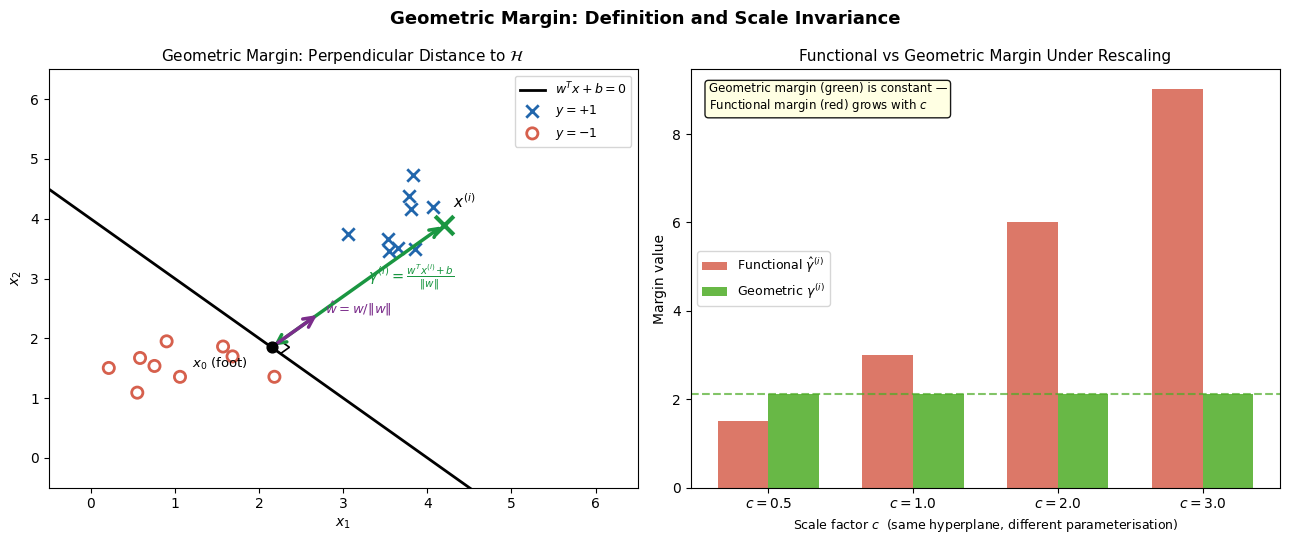

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

rng = np.random.default_rng(7)
pos = rng.normal(loc=[3.8, 4.0], scale=0.55, size=(9, 2))
neg = rng.normal(loc=[1.6, 1.8], scale=0.55, size=(9, 2))

w = np.array([1., 1.])
b = -4.0
wn = w / np.linalg.norm(w)
xr = np.linspace(-0.5, 6.5, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ─── Left: geometric margin derivation diagram ───────────────────────────
ax = axes[0]
ax.plot(xr, 4 - xr, 'k-', lw=2, label='$w^Tx+b=0$')
ax.scatter(pos[:, 0], pos[:, 1], marker='x', s=80, c='#2166ac', linewidths=2, label='$y=+1$')
ax.scatter(neg[:, 0], neg[:, 1], marker='o', s=65, facecolors='none',
           edgecolors='#d6604d', linewidths=2, label='$y=-1$')

A = np.array([4.2, 3.9])
gamma_A = (w @ A + b) / np.linalg.norm(w)
# foot of perpendicular
B = A - gamma_A * wn

ax.scatter(*A, marker='x', s=180, c='#1a9641', linewidths=3, zorder=7)
ax.scatter(*B, s=60, c='k', zorder=7)

# perpendicular line A→B
ax.annotate('', xytext=A, xy=B,
            arrowprops=dict(arrowstyle='<->', color='#1a9641', lw=2.5, mutation_scale=16))
mid = (A + B) / 2
ax.text(mid[0] + 0.12, mid[1] + 0.08,
        r'$\gamma^{(i)} = \frac{w^Tx^{(i)}\!+b}{\|w\|}$',
        fontsize=10.5, color='#1a9641')

# w̃ arrow at B pointing into positive half-space
ax.annotate('', xytext=B, xy=B + 0.8 * wn,
            arrowprops=dict(arrowstyle='->', color='#7b2d8b', lw=2.5, mutation_scale=18))
ax.text(B[0] + 0.8 * wn[0] + 0.07, B[1] + 0.8 * wn[1],
        r'$\hat{w} = w/\|w\|$', fontsize=9.5, color='#7b2d8b')

# right-angle mark at B
t = np.array([wn[1], -wn[0]])
s = 0.15
sq = np.array([B, B + s * t, B + s * t + s * wn, B + s * wn])
ax.add_patch(plt.Polygon(sq, fill=False, edgecolor='k', lw=1.2))

ax.annotate('$x^{(i)}$', A, xytext=(A[0] + 0.1, A[1] + 0.28), fontsize=11)
ax.annotate('$x_0$ (foot)', B, xytext=(B[0] - 0.95, B[1] - 0.35), fontsize=9.5)

ax.set_xlim(-0.5, 6.5); ax.set_ylim(-0.5, 6.5)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Geometric Margin: Perpendicular Distance to $\\mathcal{H}$', fontsize=11)
ax.legend(fontsize=9, loc='upper right')

# ─── Right: scale invariance demo ────────────────────────────────────────
ax = axes[1]
scales = [0.5, 1.0, 2.0, 3.0]
colors = ['#f4a582', '#ca0020', '#4dac26', '#0571b0']
pt = pos[2]
yi = +1.0

func_margins = []
geom_margins = []
for c in scales:
    wc = c * w
    bc = c * b
    fm = yi * (wc @ pt + bc)
    gm = fm / np.linalg.norm(wc)
    func_margins.append(fm)
    geom_margins.append(gm)

x = np.arange(len(scales))
width = 0.35
bars1 = ax.bar(x - width / 2, func_margins, width, label='Functional $\\hat{\\gamma}^{(i)}$',
               color='#d6604d', alpha=0.85)
bars2 = ax.bar(x + width / 2, geom_margins, width, label='Geometric $\\gamma^{(i)}$',
               color='#4dac26', alpha=0.85)

ax.axhline(geom_margins[0], color='#4dac26', lw=1.5, ls='--', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels([f'$c={c}$' for c in scales])
ax.set_xlabel('Scale factor $c$  (same hyperplane, different parameterisation)', fontsize=9)
ax.set_ylabel('Margin value', fontsize=10)
ax.set_title('Functional vs Geometric Margin Under Rescaling', fontsize=11)
ax.legend(fontsize=9)
ax.text(0.03, 0.97,
        'Geometric margin (green) is constant —\nFunctional margin (red) grows with $c$',
        transform=ax.transAxes, fontsize=8.5, va='top',
        bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9))

fig.suptitle('Geometric Margin: Definition and Scale Invariance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Scale Invariance of the Geometric Margin

### Formal proof

**Claim:** For any $c > 0$, replacing $(w, b)$ with $(cw, cb)$ leaves $\gamma^{(i)}$ unchanged.

**Proof:**

$$\gamma_c^{(i)} = \frac{y^{(i)}\bigl((cw)^T x^{(i)} + cb\bigr)}{\|cw\|} = \frac{c \cdot y^{(i)}\bigl(w^T x^{(i)} + b\bigr)}{c \cdot \|w\|} = \frac{y^{(i)}\bigl(w^T x^{(i)} + b\bigr)}{\|w\|} = \gamma^{(i)}$$

The factor $c$ cancels. $\square$

This confirms that the geometric margin is a **purely geometric** quantity — it depends only on where the hyperplane sits in space, not on which $(w, b)$ parameterisation we use to describe it.

### Summary: functional vs geometric margin

| Property | Functional $\hat{\gamma}^{(i)}$ | Geometric $\gamma^{(i)}$ |
|---|---|---|
| Formula | $y^{(i)}(w^T x^{(i)} + b)$ | $y^{(i)}(w^T x^{(i)} + b) / \|w\|$ |
| Scale-invariant? | No — scales with $c$ | Yes — invariant to rescaling |
| Physical units | Depends on $\|w\|$ | Same units as $x$ (a true distance) |
| Correct classification | $\hat{\gamma}^{(i)} > 0$ | $\gamma^{(i)} > 0$ |
| Used in SVM objective? | Indirectly (canonical form) | Yes — we maximise $\gamma$ |

## 5. Canonical Form and the Margin Width

### Exploiting scale freedom

Because $(cw, cb)$ and $(w, b)$ describe the same hyperplane for any $c > 0$, we have a **free choice of scale**. We use it to impose a convenient normalisation:

$$\boxed{\min_{i} \hat{\gamma}^{(i)} = 1 \quad \Longleftrightarrow \quad \min_{i}\; y^{(i)}(w^T x^{(i)} + b) = 1}$$

This is the **canonical (unit) form**. It fixes the scale of $(w, b)$ uniquely so that the nearest training point has functional margin exactly 1.

### Margin width under canonical form

Under the canonical form, the nearest training point has geometric margin:

$$\gamma = \frac{\min_i \hat{\gamma}^{(i)}}{\|w\|} = \frac{1}{\|w\|}$$

There is a nearest point on the **positive** side (on or touching $w^T x + b = +1$) and a nearest point on the **negative** side (on or touching $w^T x + b = -1$). The total **margin width** — the perpendicular gap between these two margin hyperplanes — is:

$$\text{margin width} = \gamma_{+} + \gamma_{-} = \frac{1}{\|w\|} + \frac{1}{\|w\|} = \frac{2}{\|w\|}$$

### The three hyperplanes

| Hyperplane | Equation | Role |
|---|---|---|
| Positive margin | $w^T x + b = +1$ | Closest positive training points lie here |
| Decision boundary | $w^T x + b = 0$ | Classification threshold |
| Negative margin | $w^T x + b = -1$ | Closest negative training points lie here |

The distance from the positive margin hyperplane to the decision boundary, and from the decision boundary to the negative margin hyperplane, are both $\tfrac{1}{\|w\|}$.

## Margin Illustration

The diagram below brings together every margin concept on one figure:
functional margin values, geometric margin distances, the three canonical
hyperplanes, and the $2/\|w\|$ margin width.

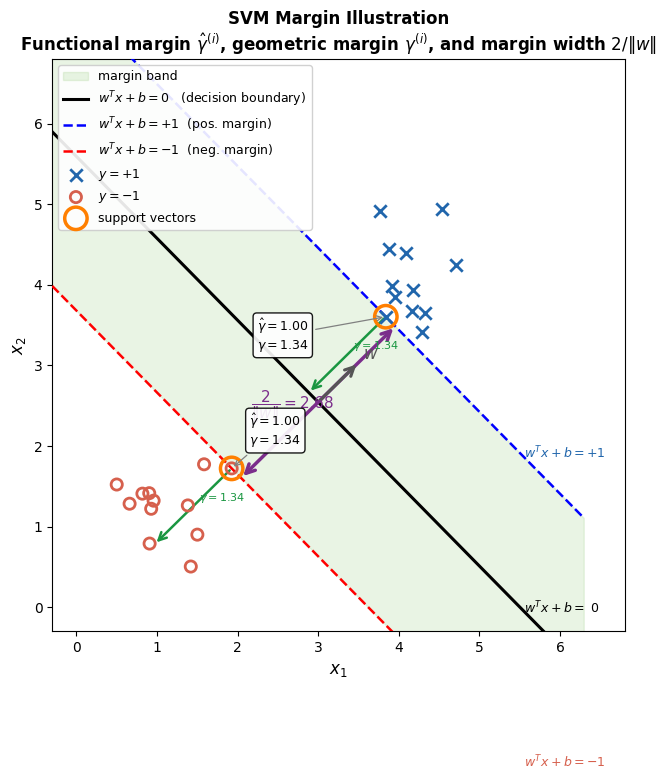

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.svm import SVC

# ── reproducible toy data ──────────────────────────────────────────────────
rng = np.random.default_rng(5)
pos = rng.normal(loc=[4.2, 4.2], scale=0.45, size=(12, 2))
neg = rng.normal(loc=[1.4, 1.4], scale=0.45, size=(12, 2))
X   = np.vstack([pos, neg])
y   = np.hstack([np.ones(12), -np.ones(12)])

clf = SVC(kernel='linear', C=1e6)
clf.fit(X, y)
w, b = clf.coef_[0], clf.intercept_[0]
wn   = w / np.linalg.norm(w)       # unit normal

xr = np.linspace(-0.3, 6.3, 400)

fig, ax = plt.subplots(figsize=(9, 8))

# ── filled margin band ─────────────────────────────────────────────────────
yr_pos = -(w[0]*xr + b - 1) / w[1]
yr_neg = -(w[0]*xr + b + 1) / w[1]
yr_db  = -(w[0]*xr + b    ) / w[1]
ax.fill_between(xr, yr_neg, yr_pos, alpha=0.12, color='#4dac26', label='margin band')

# ── three hyperplanes ──────────────────────────────────────────────────────
ax.plot(xr, yr_db,  'k-',  lw=2.2, label='$w^Tx+b=0$   (decision boundary)', zorder=3)
ax.plot(xr, yr_pos, 'b--', lw=1.8, label='$w^Tx+b=+1$  (pos. margin)', zorder=3)
ax.plot(xr, yr_neg, 'r--', lw=1.8, label='$w^Tx+b=-1$  (neg. margin)', zorder=3)

# ── training points ────────────────────────────────────────────────────────
ax.scatter(pos[:,0], pos[:,1], marker='x', s=80,  c='#2166ac', linewidths=2,   zorder=4, label='$y=+1$')
ax.scatter(neg[:,0], neg[:,1], marker='o', s=65, facecolors='none',
           edgecolors='#d6604d', linewidths=2, zorder=4, label='$y=-1$')

# ── support vectors ────────────────────────────────────────────────────────
sv = clf.support_vectors_
ax.scatter(sv[:,0], sv[:,1], s=260, facecolors='none',
           edgecolors='#ff7f00', linewidths=2.5, zorder=5, label='support vectors')

# ── geometric margin arrows: sv → decision boundary ───────────────────────
for xi in sv:
    yi_val = 1.0 if (w @ xi + b) > 0 else -1.0
    gm     = yi_val * (w @ xi + b) / np.linalg.norm(w)
    foot   = xi - gm * wn               # foot of perpendicular on boundary
    ax.annotate('', xy=foot, xytext=xi,
                arrowprops=dict(arrowstyle='->', color='#1a9641',
                                lw=1.8, mutation_scale=14))
    mid = (xi + foot) / 2
    ax.text(mid[0]+0.07, mid[1]+0.07,
            f'$\\gamma={gm:.2f}$', fontsize=8, color='#1a9641', zorder=7)

# ── margin width double-headed arrow (perpendicular to boundary) ───────────
# pick a point on the decision boundary mid-figure
xm_db  = 3.0
ym_db  = -(w[0]*xm_db + b) / w[1]
pt_db  = np.array([xm_db, ym_db])

half_w = 1.0 / np.linalg.norm(w)      # distance from boundary to each margin line
pt_pos = pt_db + half_w * wn          # on positive margin line
pt_neg = pt_db - half_w * wn          # on negative margin line

ax.annotate('', xy=pt_pos, xytext=pt_neg,
            arrowprops=dict(arrowstyle='<->', color='#7b2d8b',
                            lw=2.5, mutation_scale=16))
ax.text(pt_neg[0]+0.12, (pt_pos[1]+pt_neg[1])/2 - 0.06,
        f'$\\dfrac{{2}}{{\\|w\\|}} = {2*half_w:.2f}$',
        fontsize=11, color='#7b2d8b', va='center', zorder=7)

# ── functional margin annotation for one positive and one negative sv ──────
for xi, label_txt, offset in [
    (sv[0], '$\\hat{\\gamma}^{(i)} = y^{(i)}(w^Tx^{(i)}+b)$', (0.22, 0.30)),
    (sv[-1],'$\\hat{\\gamma}^{(i)} = y^{(i)}(w^Tx^{(i)}+b)$', (-1.6,-0.40)),
]:
    yi_val = 1.0 if (w @ xi + b) > 0 else -1.0
    fm     = yi_val * (w @ xi + b)
    gm     = fm / np.linalg.norm(w)
    ax.annotate(
        f'$\\hat{{\\gamma}}={fm:.2f}$\n$\\gamma={gm:.2f}$',
        xi, xytext=(xi[0]+offset[0], xi[1]+offset[1]), fontsize=9,
        arrowprops=dict(arrowstyle='->', color='gray', lw=0.9),
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.9), zorder=8
    )

# ── w direction arrow ──────────────────────────────────────────────────────
ax.annotate('', xytext=pt_db, xy=pt_db + 0.7*wn,
            arrowprops=dict(arrowstyle='->', color='#555',
                            lw=2.2, mutation_scale=16))
ax.text(pt_db[0]+0.7*wn[0]+0.06, pt_db[1]+0.7*wn[1]+0.04,
        '$w$', fontsize=12, color='#555', fontweight='bold')

# ── labels on hyperplane lines ────────────────────────────────────────────
for yr_line, txt, col in [
    (yr_pos, '$w^Tx+b=+1$', '#2166ac'),
    (yr_db,  '$w^Tx+b=\\ 0$',   'black'),
    (yr_neg, '$w^Tx+b=-1$', '#d6604d'),
]:
    idx = np.argmin(np.abs(xr - 5.5))
    ax.text(xr[idx]+0.05, yr_line[idx], txt, fontsize=9, color=col, va='center')

ax.set_xlim(-0.3, 6.8); ax.set_ylim(-0.3, 6.8)
ax.set_xlabel('$x_1$', fontsize=12); ax.set_ylabel('$x_2$', fontsize=12)
ax.set_title(
    'SVM Margin Illustration\n'
    r'Functional margin $\hat{\gamma}^{(i)}$, geometric margin $\gamma^{(i)}$, '
    r'and margin width $2/\|w\|$',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()


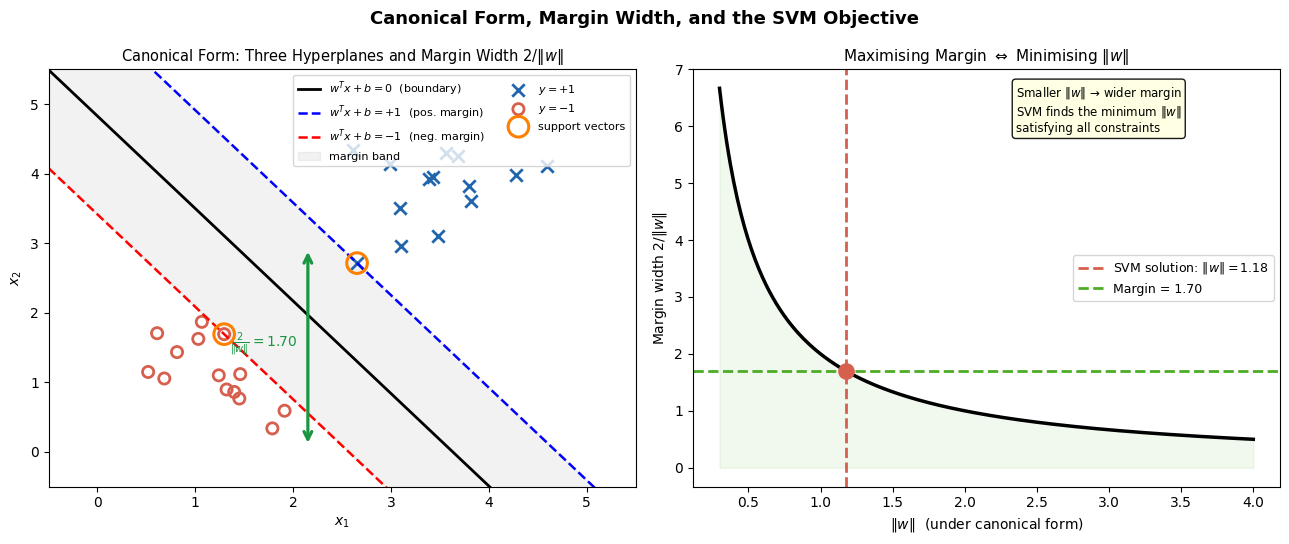

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# canonical SVM solution on a small 2-D dataset
from sklearn.svm import SVC

rng = np.random.default_rng(21)
pos = rng.normal(loc=[3.5, 3.5], scale=0.5, size=(14, 2))
neg = rng.normal(loc=[1.2, 1.2], scale=0.5, size=(14, 2))
X = np.vstack([pos, neg])
y = np.hstack([np.ones(14), -np.ones(14)])

clf = SVC(kernel='linear', C=1e6)
clf.fit(X, y)

w = clf.coef_[0]
b = clf.intercept_[0]
wn = w / np.linalg.norm(w)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ─── Left: canonical form — three hyperplanes ────────────────────────────
ax = axes[0]
xr = np.linspace(-0.5, 5.5, 300)

# decision boundary
yr_db = -(w[0] * xr + b) / w[1]
ax.plot(xr, yr_db, 'k-', lw=2, label='$w^Tx+b=0$  (boundary)')

# positive margin hyperplane
yr_pos = -(w[0] * xr + b - 1) / w[1]
ax.plot(xr, yr_pos, 'b--', lw=1.8, label='$w^Tx+b=+1$  (pos. margin)')

# negative margin hyperplane
yr_neg = -(w[0] * xr + b + 1) / w[1]
ax.plot(xr, yr_neg, 'r--', lw=1.8, label='$w^Tx+b=-1$  (neg. margin)')

# fill margin band
ax.fill_between(xr, yr_neg, yr_pos, alpha=0.10, color='gray', label='margin band')

ax.scatter(pos[:, 0], pos[:, 1], marker='x', s=80, c='#2166ac', linewidths=2, label='$y=+1$')
ax.scatter(neg[:, 0], neg[:, 1], marker='o', s=65, facecolors='none',
           edgecolors='#d6604d', linewidths=2, label='$y=-1$')

# highlight support vectors
sv = clf.support_vectors_
ax.scatter(sv[:, 0], sv[:, 1], s=220, facecolors='none',
           edgecolors='#ff7f00', linewidths=2.2, zorder=8, label='support vectors')

# annotate margin width
xm = 2.5
ym_db = -(w[0] * xm + b) / w[1]
ym_pos = -(w[0] * xm + b - 1) / w[1]
ym_neg = -(w[0] * xm + b + 1) / w[1]
ax.annotate('', xy=(xm - 0.35, ym_pos), xytext=(xm - 0.35, ym_neg),
            arrowprops=dict(arrowstyle='<->', color='#1a9641', lw=2.3, mutation_scale=14))
margin_w = 2.0 / np.linalg.norm(w)
ax.text(xm - 1.15, (ym_pos + ym_neg) / 2,
        f'$\\frac{{2}}{{\\|w\\|}} = {margin_w:.2f}$', fontsize=10, color='#1a9641')

ax.set_xlim(-0.5, 5.5); ax.set_ylim(-0.5, 5.5)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Canonical Form: Three Hyperplanes and Margin Width $2/\\|w\\|$', fontsize=10.5)
ax.legend(fontsize=8, loc='upper right', ncol=2)

# ─── Right: margin width vs ‖w‖ trade-off ────────────────────────────────
ax = axes[1]
norm_w = np.linspace(0.3, 4.0, 300)
margin_width = 2.0 / norm_w

ax.plot(norm_w, margin_width, 'k-', lw=2.5)
ax.axvline(np.linalg.norm(w), color='#d6604d', lw=2, ls='--',
           label=f'SVM solution: $\\|w\\|={np.linalg.norm(w):.2f}$')
ax.axhline(margin_w, color='#4dac26', lw=2, ls='--',
           label=f'Margin = {margin_w:.2f}')
ax.scatter([np.linalg.norm(w)], [margin_w], s=120, color='#d6604d', zorder=6)

ax.fill_between(norm_w, margin_width, alpha=0.08, color='#4dac26')

ax.set_xlabel('$\\|w\\|$  (under canonical form)', fontsize=10)
ax.set_ylabel('Margin width $2/\\|w\\|$', fontsize=10)
ax.set_title('Maximising Margin $\\Leftrightarrow$ Minimising $\\|w\\|$', fontsize=11)
ax.legend(fontsize=9)
ax.text(0.55, 0.85,
        'Smaller $\\|w\\|$ → wider margin\nSVM finds the minimum $\\|w\\|$\nsatisfying all constraints',
        transform=ax.transAxes, fontsize=8.5,
        bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9))

fig.suptitle('Canonical Form, Margin Width, and the SVM Objective', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Numerical Verification

The code below confirms all margin relationships numerically on a small dataset:

1. $\gamma^{(i)} = \hat{\gamma}^{(i)} / \|w\|$ for every training point
2. Under canonical form, $\min_i \hat{\gamma}^{(i)} = 1$
3. The training set margin equals $1 / \|w\|$
4. Rescaling $(w, b)$ preserves $\gamma^{(i)}$ but changes $\hat{\gamma}^{(i)}$

In [20]:
import numpy as np
from sklearn.svm import SVC

rng = np.random.default_rng(99)
pos = rng.normal(loc=[3.0, 3.0], scale=0.6, size=(8, 2))
neg = rng.normal(loc=[1.0, 1.0], scale=0.6, size=(8, 2))
X = np.vstack([pos, neg])
y = np.hstack([np.ones(8), -np.ones(8)])

clf = SVC(kernel='linear', C=1e6)
clf.fit(X, y)
w = clf.coef_[0]
b = clf.intercept_[0]

norm_w = np.linalg.norm(w)
func_margins = y * (X @ w + b)
geom_margins = func_margins / norm_w

print('=== Canonical Form Check ===')
print(f'  ||w||                        = {norm_w:.4f}')
print(f'  min functional margin        = {func_margins.min():.4f}  (should be ≈ 1)')
print(f'  min geometric margin (γ)     = {geom_margins.min():.4f}  (= 1/||w||)')
print(f'  1/||w||                      = {1/norm_w:.4f}')
print(f'  Margin width 2/||w||         = {2/norm_w:.4f}')

print()
print('=== Functional vs Geometric Margins (first 5 points) ===')
print(f'{"Point":<8} {"y":<5} {"func_margin":<16} {"geom_margin":<16}')
for i in range(5):
    print(f'  {i:<6} {int(y[i]):<5} {func_margins[i]:<16.4f} {geom_margins[i]:<16.4f}')

print()
print('=== Scale Invariance Check (c=3) ===')
c = 3.0
func_margins_scaled = y * (X @ (c * w) + c * b)
geom_margins_scaled = func_margins_scaled / np.linalg.norm(c * w)
print(f'  Functional margins scaled by c=3: {func_margins_scaled[:3].round(4)}')
print(f'  Original functional margins:      {func_margins[:3].round(4)}')
print(f'  Geometric margins after scaling:  {geom_margins_scaled[:3].round(4)}')
print(f'  Original geometric margins:       {geom_margins[:3].round(4)}')
print(f'  Max difference in geometric margin: {np.abs(geom_margins - geom_margins_scaled).max():.2e}')

=== Canonical Form Check ===
  ||w||                        = 1.2092
  min functional margin        = 1.0000  (should be ≈ 1)
  min geometric margin (γ)     = 0.8270  (= 1/||w||)
  1/||w||                      = 0.8270
  Margin width 2/||w||         = 1.6540

=== Functional vs Geometric Margins (first 5 points) ===
Point    y     func_margin      geom_margin     
  0      1     1.3409           1.1089          
  1      1     1.9262           1.5930          
  2      1     1.5386           1.2724          
  3      1     1.0000           0.8270          
  4      1     1.5024           1.2425          

=== Scale Invariance Check (c=3) ===
  Functional margins scaled by c=3: [4.0226 5.7786 4.6158]
  Original functional margins:      [1.3409 1.9262 1.5386]
  Geometric margins after scaling:  [1.1089 1.593  1.2724]
  Original geometric margins:       [1.1089 1.593  1.2724]
  Max difference in geometric margin: 8.88e-16


## 7. Connecting Margins to the SVM Optimisation Problem

The margin analysis so far feeds directly into the SVM objective:

### The SVM goal (informal)

Find $(w, b)$ that correctly classifies all training points and **maximises the geometric margin** $\gamma$.

### Under canonical form

Canonical form sets $\min_i \hat{\gamma}^{(i)} = 1$, so:

$$\gamma = \frac{1}{\|w\|}$$

Maximising $\gamma = 1/\|w\|$ is equivalent to minimising $\|w\|$, which is equivalent to minimising $\tfrac{1}{2}\|w\|^2$:

$$\max_{w,b} \; \frac{1}{\|w\|} \quad \equiv \quad \min_{w,b} \; \frac{1}{2}\|w\|^2$$

subject to all training points satisfying $y^{(i)}(w^T x^{(i)} + b) \geq 1$.

This is the **Primal QP** — a strictly convex quadratic program.

### Derivation pathway

In [21]:
from IPython.display import HTML
HTML("""
<svg xmlns="http://www.w3.org/2000/svg" width="760" height="374"
     viewBox="0 0 760 374" font-family="Segoe UI, Arial, sans-serif">
  <defs>
    <marker id="ah" markerWidth="10" markerHeight="7" refX="9" refY="3.5"
            orient="auto" markerUnits="userSpaceOnUse">
      <polygon points="0 0,10 3.5,0 7" fill="#444"/>
    </marker>
    <marker id="ahd" markerWidth="10" markerHeight="7" refX="9" refY="3.5"
            orient="auto" markerUnits="userSpaceOnUse">
      <polygon points="0 0,10 3.5,0 7" fill="#999"/>
    </marker>
  </defs>

  <!-- Row 1: Functional margin -->
  <rect x="10" y="12" width="175" height="46" rx="7"
        fill="#ffffff" stroke="#2166ac" stroke-width="2"/>
  <text x="97" y="40" font-size="14" font-weight="600"
        text-anchor="middle" fill="#2166ac">Functional margin</text>
  <line x1="187" y1="35" x2="206" y2="35"
        stroke="#444" stroke-width="2" marker-end="url(#ah)"/>
  <rect x="211" y="12" width="538" height="46" rx="7"
        fill="#eef2f7" stroke="#b0bec5" stroke-width="1.5"/>
  <text x="480" y="40" font-size="13" text-anchor="middle" fill="#333"
        >scale-sensitive, not suitable for optimisation</text>

  <!-- step label 1→2 -->
  <line x1="97" y1="58" x2="97" y2="108"
        stroke="#999" stroke-width="1.8" stroke-dasharray="5,3"
        marker-end="url(#ahd)"/>
  <text x="109" y="82" font-size="11.5" font-style="italic" fill="#555"
        >normalise by &#x2016;w&#x2016;</text>

  <!-- Row 2: Geometric margin -->
  <rect x="10" y="112" width="175" height="46" rx="7"
        fill="#ffffff" stroke="#2166ac" stroke-width="2"/>
  <text x="97" y="140" font-size="14" font-weight="600"
        text-anchor="middle" fill="#2166ac">Geometric margin</text>
  <line x1="187" y1="135" x2="206" y2="135"
        stroke="#444" stroke-width="2" marker-end="url(#ah)"/>
  <rect x="211" y="112" width="538" height="46" rx="7"
        fill="#eef2f7" stroke="#b0bec5" stroke-width="1.5"/>
  <text x="480" y="140" font-size="13" text-anchor="middle" fill="#333"
        >scale-invariant, physically meaningful distance</text>

  <!-- step label 2→3 -->
  <line x1="97" y1="158" x2="97" y2="218"
        stroke="#999" stroke-width="1.8" stroke-dasharray="5,3"
        marker-end="url(#ahd)"/>
  <text x="109" y="178" font-size="11.5" font-style="italic" fill="#555"
        >fix scale via canonical form</text>
  <text x="109" y="196" font-size="11.5" font-style="italic" fill="#555"
        >(min functional margin = 1)</text>

  <!-- Row 3: gamma = 1/||w|| -->
  <rect x="10" y="222" width="175" height="46" rx="7"
        fill="#ffffff" stroke="#2166ac" stroke-width="2"/>
  <text x="97" y="250" font-size="14" font-weight="600"
        text-anchor="middle" fill="#2166ac">&#x3b3; = 1/&#x2016;w&#x2016;</text>
  <line x1="187" y1="245" x2="206" y2="245"
        stroke="#444" stroke-width="2" marker-end="url(#ah)"/>
  <rect x="211" y="222" width="538" height="46" rx="7"
        fill="#eef2f7" stroke="#b0bec5" stroke-width="1.5"/>
  <text x="480" y="250" font-size="13" text-anchor="middle" fill="#333"
        >maximise &#x3b3; &#x27fa; minimise &#xbd;&#x2016;w&#x2016;&#xb2;</text>

  <!-- step arrow 3→4 -->
  <line x1="97" y1="268" x2="97" y2="316"
        stroke="#999" stroke-width="1.8" stroke-dasharray="5,3"
        marker-end="url(#ahd)"/>

  <!-- Row 4: Primal QP -->
  <rect x="10" y="320" width="175" height="46" rx="7"
        fill="#1a5fa8" stroke="#1a5fa8" stroke-width="2"/>
  <text x="97" y="348" font-size="14" font-weight="700"
        text-anchor="middle" fill="#ffffff">Primal QP</text>
  <line x1="187" y1="343" x2="206" y2="343"
        stroke="#444" stroke-width="2" marker-end="url(#ah)"/>
  <rect x="211" y="320" width="538" height="46" rx="7"
        fill="#dce8f8" stroke="#7aadd4" stroke-width="1.5"/>
  <text x="480" y="348" font-size="13" text-anchor="middle" fill="#333"
        >solved via Lagrangian duality</text>
</svg>
""")


## Summary

| Concept | Formula | Key property |
|---|---|---|
| Functional margin (per-point) | $\hat{\gamma}^{(i)} = y^{(i)}(w^T x^{(i)} + b)$ | Positive iff correctly classified; scales with $\|w\|$ |
| Functional margin (dataset) | $\hat{\gamma} = \min_i \hat{\gamma}^{(i)}$ | Confidence on hardest training point |
| Geometric margin (per-point) | $\gamma^{(i)} = \hat{\gamma}^{(i)} / \|w\|$ | True perpendicular distance; scale-invariant |
| Geometric margin (dataset) | $\gamma = \min_i \gamma^{(i)}$ | The quantity SVM maximises |
| Canonical form | $\min_i \hat{\gamma}^{(i)} = 1$ | Fixes scale freedom; $\gamma = 1/\|w\|$ |
| Margin width | $2/\|w\|$ | Gap between positive and negative margin hyperplanes |
| SVM primal QP | $\min \tfrac{1}{2}\|w\|^2$ s.t. $y^{(i)}(w^T x^{(i)}+b) \geq 1$ | Equivalent to maximising geometric margin |

**Key insight:** the geometric margin is the right quantity to optimise because it is a true Euclidean distance, independent of the parameterisation $(w, b)$. The canonical form converts the scale-free margin maximisation into a well-posed QP.